# Разработка A/B-тестирования и анализ результатов

# Цель исследования
Для компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео рассчитать параметры A/B-теста и проанализировать его результаты, чтобы проверить гипотезу: команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

# Задачи исследования
* Рассчитать параметры теста;
* Оценить корректность его проведения и проанализировать результаты эксперимента.

---
# Описание данных

Будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

---
<a id='start'></a>
# Содержание:
 
***1 Работа с историческими данными (EDA)***

[1.1 Загрузка исторических данных](#1)

[1.2 Знакомство с данными](#2)

[1.3 Анализ числа регистраций](#3)

[1.4 Анализ числа просмотренных страниц](#4)

[1.5 Доля пользователей, просмотревших более четырёх страниц](#5)

***2 Подготовка к тесту***

[2.1 Расчёт размера выборки](#6)

[2.2 Расчёт длительности A/B-теста](#7)

***3 Мониторинг А/В-теста***

[3.1 Проверка распределения пользователей](#8)

[3.2 Проверка пересечений пользователей](#9)

[3.3 Равномерность разделения пользователей по устройствам](#10)

[3.4 Равномерность распределения пользователей по регионам](#11)

[3.5 Вывод после проверки A/B-теста](#12)

***4 Проверка результатов A/B-теста***

[4.1 Получение результатов теста и подсчёт основной метрики](#13)

[4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик¶](#14)

[4.3 Сравнение доли успешных первых сессий](#15)

[4.4 Насколько статистически значимо изменение ключевой метрики](#16)

[4.5 Вывод по результатам A/B-эксперимента](#17)

---
## Работа с историческими данными (EDA)
<a id='1'></a>
### Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

In [2]:
# Выгружаем данные в переменную df_sessions_history
df_sessions_history = pd.read_csv('.csv')

In [3]:
# Выводим первые строки датафрейма на экран
df_sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
# Выводим информацию о датафрейме
df_sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


Датасет `sessions_project_history.csv` содержит 10 столбцов и 435 924 строк, в которых представлена информация о сессиях пользователей на период с 2025-08-15 по 2025-09-23.

После первичного анализа данных можно сделать следующие выводы:

* Названия столбцов отображаются корректно.
* В столбцах, содержащих дату, преобразуем тип данных в `datetime64`. В остальных столбцах типы данных оптимальны.
* Пропусков в столбцах нет.
* Значения в столбцах соответствуют своему описанию.

In [5]:
# Преобразуем столбцы с датами в datetime64
datetime_cols = ['session_date', 'session_start_ts', 'install_date']

for col in datetime_cols:
    df_sessions_history[col] = pd.to_datetime(df_sessions_history[col], errors='coerce')

# Проверим результат
df_sessions_history.dtypes

user_id                      object
session_id                   object
session_date         datetime64[ns]
session_start_ts     datetime64[ns]
install_date         datetime64[ns]
session_number                int64
registration_flag             int64
page_counter                  int64
region                       object
device                       object
dtype: object

---
<a id='2'></a>
### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [6]:
# Рассчитаем количество уникальных session_id для каждого уникального user_id
user_sessions = (
    df_sessions_history.groupby('user_id')['session_id']
    .nunique()
    .reset_index(name='unique_sessions_count')
    .sort_values(by='unique_sessions_count', ascending=False)
)

# Выведем результат
user_sessions.head(10)

,user_id,unique_sessions_count
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9
22611,2AF89E9BC4D631A3,9
29354,37E4825C6A22A519,9
53434,66374F4203EFEDA7,9
16936,1FE6E098C8A7E9A3,9
84534,A1E1B4CCA664587C,9


In [7]:
# Выбираем пользователя с наибольшим числом сессий
top_user_id = user_sessions.iloc[0]['user_id']

# Фильтруем исходную таблицу по этому пользователю
top_user_data = df_sessions_history[df_sessions_history['user_id'] == top_user_id]

# Выводим все данные для этого пользователя
top_user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


***ВЫВОД:*** Проанализировав таблицу для одного пользователя можно увидить такие закономерности: пользователь впервые зашел в приложение в день его установки, поведенческая метрика меняется от сессии к сессии - количество просмотренных страниц разное для каждой сессии, время старта сессии также разное. Сессии идут не каждый день. Атрибуты пользователя (статус регистрации, регион, тип устройства) не меняются на протяжении всех сессий.

---
<a id='3'></a>
### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [8]:
# Считаем число уникальных пользователей для каждого дня
daily_unique_users = (
    df_sessions_history.groupby('session_date')['user_id']
    .nunique()
    .reset_index(name='total_users')
)

In [9]:
# Считаем число зарегистрированных пользователей для каждого дня
daily_registered_users = (
    df_sessions_history[df_sessions_history['registration_flag'] == 1]
    .groupby('session_date')['user_id']
    .nunique()
    .reset_index(name='registered_users')
)

In [10]:
# Объединяем
daily_stats = pd.merge(
    daily_unique_users,
    daily_registered_users,
    on='session_date',
    how='left'
)
daily_stats['registered_users'] = daily_stats['registered_users'].fillna(0).astype(int)
daily_stats = daily_stats.sort_values('session_date').reset_index(drop=True)

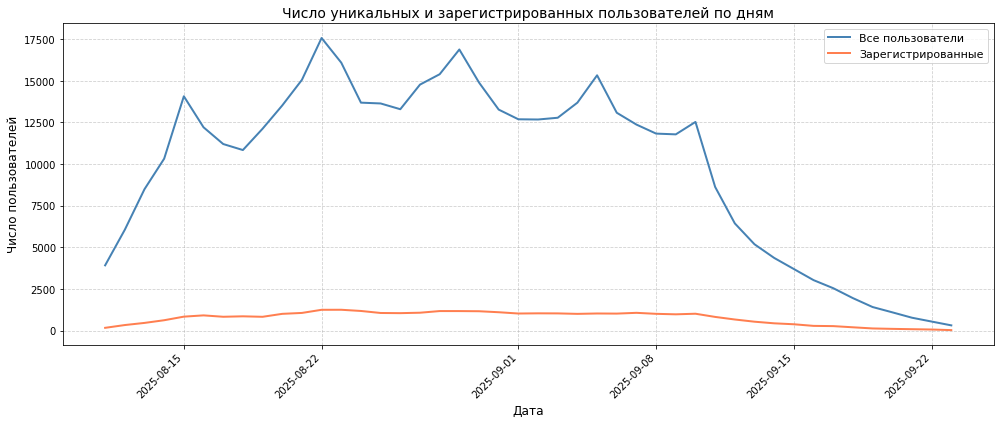

In [11]:
# График: общее число пользователей и зарегистрированных
# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(14, 6))

# Строим график
ax.plot(daily_stats['session_date'], daily_stats['total_users'],
        label='Все пользователи', color='steelblue', linewidth=2)
ax.plot(daily_stats['session_date'], daily_stats['registered_users'],
        label='Зарегистрированные', color='coral', linewidth=2)

# Оформляем титул и название осей
ax.set_title('Число уникальных и зарегистрированных пользователей по дням', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Число пользователей', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()

# Выводи график
plt.show()

In [12]:
# Считаем долю зарегистрированных пользователей
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']

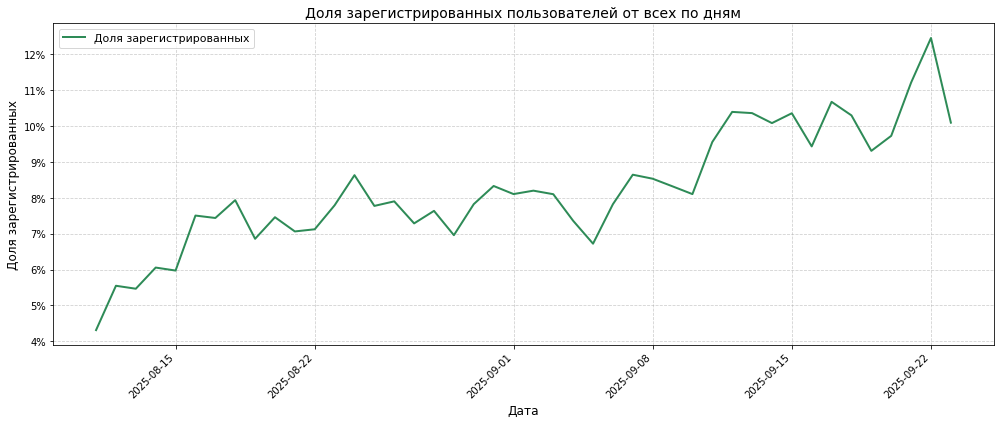

In [13]:
# График: доля зарегистрированных польз-лей
# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(14, 6))

# Строим график
ax.plot(daily_stats['session_date'], daily_stats['registered_share'],
        label='Доля зарегистрированных', color='seagreen', linewidth=2)

# Оформление титула и подписи осей
ax.set_title('Доля зарегистрированных пользователей от всех по дням', fontsize=14)
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Доля зарегистрированных', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
fig.autofmt_xdate(rotation=45)

# Формат оси Y — проценты
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()

# Вывод графика
plt.show()

***ВЫВОД:*** 

В графике `Число уникальных и зарегистрированных пользователей по дням` наблюдаем следующие закономерности: 
- рост в начале периода (примерно до 22 августа). Число всех пользователей резко увеличивается с ~4 000 до ~14 000. Зарегистрированные пользователи растут более плавно и незначительно — с ~500 до ~1 200. Это может говорить о всплеске органического трафика или запуске масштабной рекламной кампании, которая привлекла много новых посетителей, но не все из них прошли регистрацию.
- волатильность в середине периода (конец августа — начало сентября). Заметны колебания по числу пользователей: пики до ~17 500 и спады до ~12 500–13 500. Число зарегистрированных остаётся относительно стабильным на уровне ~1 000–1 300. Такая динамика может быть связана с цикличностью активности (например, недельные циклы), промоакциями или внешними факторами (релизы, публикации в СМИ).
- резкий и устойчивый спад с начала сентября. После ~8 сентября синяя линия демонстрирует выраженный нисходящий тренд: с ~12 500 до ~1 000 к 22 сентября. Оранжевая линия также снижается, но менее круто — примерно с ~1 100 до ~500. Причины могут быть разными: завершение рекламной кампании, сезонный спад, технические проблемы, изменение алгоритмов привлечения трафика или окончание акции, стимулировавшей регистрацию.

На графике `Доля зарегистрированных пользователей от всех по дням` показатель в целом увеличивается на протяжении всего периода с ~4-5% до ~10-11%, несмотря на локальные колебания, ~22-23 сентября фиксируется резкий скачек до ~12,5%, после чего следует быстрое снижение примерно до 10 %. Аномальный всплеск в конце сентября обусловлен сокращением числа уникальных пользователей, что видно из первого графика.

---
<a id='4'></a>
### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [14]:
# Отфильтруем первые сессии
df_first_sessions = df_sessions_history[df_sessions_history['session_number'] == 1]

In [15]:
# Подсчитаем количества первых сессий для каждого значения page_counter
page_counts = df_first_sessions['page_counter'].value_counts().sort_index()

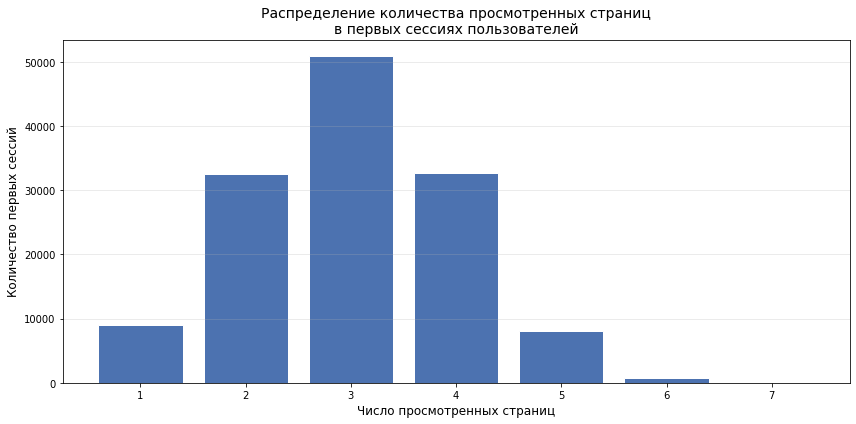

In [16]:
# Построим столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(page_counts.index, page_counts.values, color='#4C72B0', edgecolor='white')

# Оформляем заголовок и название осей
plt.title('Распределение количества просмотренных страниц\nв первых сессиях пользователей', fontsize=14)
plt.xlabel('Число просмотренных страниц', fontsize=12)
plt.ylabel('Количество первых сессий', fontsize=12)
plt.xticks(page_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

***ВЫВОД:*** В первые сессии чаще всего просматривают 3 страницы в приложении (свыше 50 000 пользователей), 2 и 4 страницы просмотрели примерно 33 000 пользователей, 1 и 5 страниц — около 8 000, а 6 и 7 страниц — существенно меньше. Подавляющее большинство первых сессий просматривает 2-4 страницы.

---
<a id='5'></a>
### Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

In [17]:
# Создаем столбец good_session 
df_sessions_history['good_session'] = (df_sessions_history['page_counter'] >= 4).astype(int)

In [18]:
# Отфильтруем первые сессии
df_first_sessions = df_sessions_history[df_sessions_history['session_number'] == 1].copy()

In [19]:
# Сгруппируем данные по дате 
# Посчитаем общее число первых сессий за день и число успешных первых сессий (где good_session==1)
daily_good_session = (
    df_first_sessions
    .groupby('session_date')
    .agg(
        total_first_sessions=('session_id', 'count'),
        successful_first_sessions=('good_session', 'sum')
    )
    .reset_index()
)

In [20]:
# Посчитаем долю успешных первых сессий
daily_good_session['share_good_first_sessions'] = (
    daily_good_session['successful_first_sessions'] / daily_good_session['total_first_sessions']
)

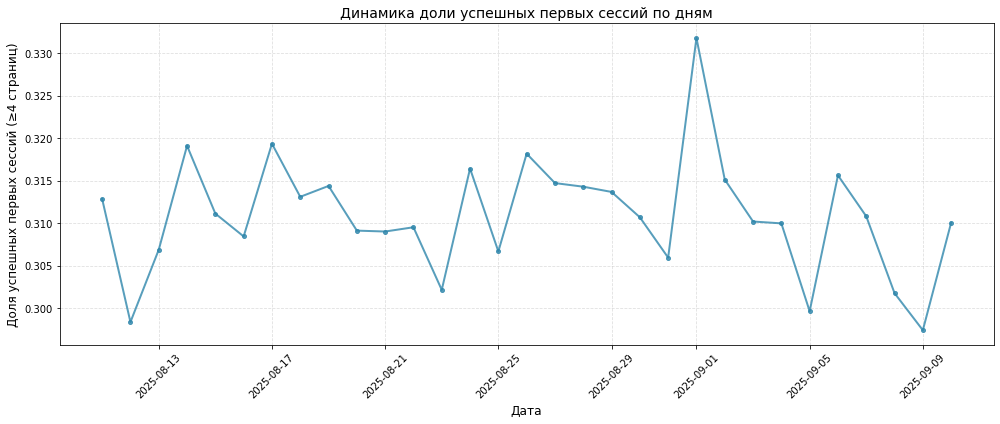

In [21]:
# Создаем фигуру и оси
plt.figure(figsize=(14, 6))

# Строим график
plt.plot(
    daily_good_session['session_date'],
    daily_good_session['share_good_first_sessions'],
    color='#2E86AB',
    linewidth=2,
    marker='o',
    markersize=4,
    alpha=0.8
)

# Оформляем титул и название осей
plt.title('Динамика доли успешных первых сессий по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных первых сессий (≥4 страниц)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()

# Выводим график
plt.show()

***ВЫВОД:*** Доля успешных сессий варьируется в узком диапазоне ~30-33%. За весь период не наблюдается последовательного роста или снижения доли успешных сессий.  Наиболее заметная аномалия — острый пик до ~33% первого сентября, который резко выделяется на фоне соседних дней, такой скачек мог быть связан с внешним фактором, но по числу пользователей общих и зарегистрированных всплеска в этот день не наблюдается. После десятого сентября успешных сессий (4 и более просмотренных страниц) нет, что связано со снижением общего числа пользователей.

[Назад к содержанию](#start)

---
## Подготовка к тесту

- Определимся с целевой метрикой.

- Рассчитаем необходимый размер выборки.

- Исходя из текущих значений трафика рассчитаем необходимую длительность проведения теста.

<a id='6'></a>
### Расчёт размера выборки

In [22]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.009  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


---
<a id='7'></a>
### Расчёт длительности A/B-теста

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [23]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(df_sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size/(avg_daily_users/2))

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


[Назад к содержанию](#start)

---
## Мониторинг А/В-теста

<a id='8'></a>
### Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [24]:
# Выгружаем данные в переменную df_sessions_test_part
df_sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [25]:
# Выведем первые строки датафрейма
df_sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [26]:
# Выводим информацию о датафрейме
df_sessions_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


Датасет `sessions_project_test_part.csv` содержит 11 столбцов и 3129 строк, в которых представлена информация о сессиях пользователей за первый день проведения A/B-теста, то есть за 2025-10-14.

* Названия столбцов отображаются корректно.
* Типы данных оптимальны.
* Пропусков в столбцах нет.
* Значения в столбцах соответствуют своему описанию.

In [27]:
# Рассчитываем количество уникальных пользователей в каждой экспериментальной группе
users_per_group = (df_sessions_test_part.groupby('test_group')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'unique_users_count'})
)


users_per_group

,test_group,unique_users_count
0,A,1477
1,B,1466


In [28]:
# Извлекаем значения А и В
count_A = users_per_group.loc[users_per_group['test_group'] == 'A', 'unique_users_count'].iloc[0]
count_B = users_per_group.loc[users_per_group['test_group'] == 'B', 'unique_users_count'].iloc[0]

# Процентная разница по формуле P = 100 * (|A - B| / A)
percent_diff = 100 * abs(count_A - count_B) / count_A

print(f"\nПроцентная разница (относительно группы A): {percent_diff:.2f}%")


Процентная разница (относительно группы A): 0.74%


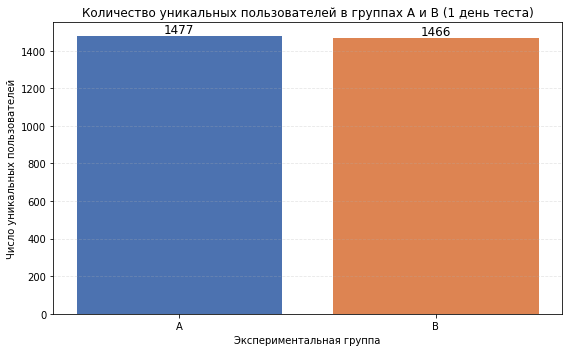

In [29]:
# Визуализация: столбчатая диаграмма
plt.figure(figsize=(8, 5))
bars = plt.bar(['A', 'B'], [count_A, count_B], color=['#4c72b0', '#dd8452'])

# Подписи значений на столбцах
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=12
    )

# Оформление названия заголовка и подписи осей
plt.title('Количество уникальных пользователей в группах A и B (1 день теста)')
plt.xlabel('Экспериментальная группа')
plt.ylabel('Число уникальных пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Вывод графика
plt.show()

---
<a id='9'></a>
### Проверка пересечений пользователей

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [30]:
# Выделяем пользователей из группы A и группы B
users_A = set(df_sessions_test_part[df_sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(df_sessions_test_part[df_sessions_test_part['test_group'] == 'B']['user_id'])

# Находим пересечение: пользователи, которые есть одновременно в обеих группах
users_in_both = users_A & users_B
count_in_both = len(users_in_both)

print(f"Количество пользователей, встречающихся одновременно в группах A и B: {count_in_both}")

Количество пользователей, встречающихся одновременно в группах A и B: 0


---
<a id='10'></a>
### Равномерность разделения пользователей по устройствам
Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

In [31]:
# Фильтруем группы
df_A = df_sessions_test_part[df_sessions_test_part['test_group'] == 'A']
df_B = df_sessions_test_part[df_sessions_test_part['test_group'] == 'B']

In [32]:
# Считаем доли устройств 
devices_A = df_A.groupby('device')['user_id'].nunique().sort_values(ascending=False)
devices_B = df_B.groupby('device')['user_id'].nunique().sort_values(ascending=False)

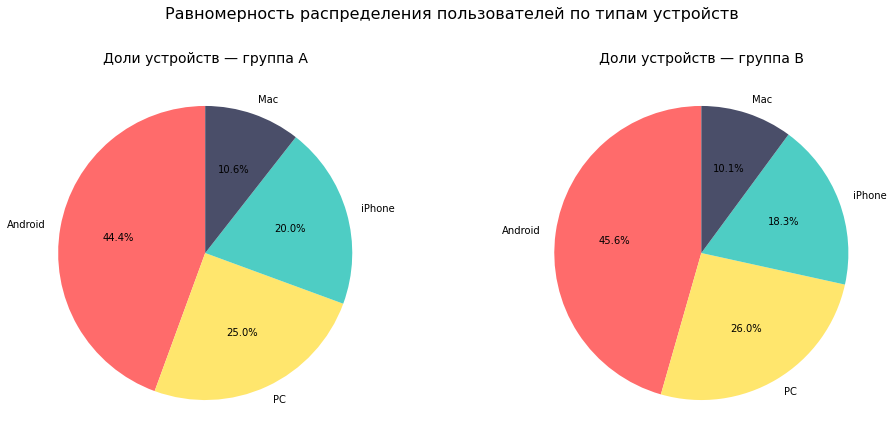

In [33]:
# Фиксированные цвета для каждого типа девайса
device_colors = {
    'Android': '#FF6B6B',   
    'iPhone': '#4ECDC4',    
    'PC': '#FFE66D',        
    'Mac': '#4A4E69'       
}

# Формируем списки цветов в том же порядке, что и данные на диаграмме
colors_A = [device_colors.get(dev, '#CCCCCC') for dev in devices_A.index]
colors_B = [device_colors.get(dev, '#CCCCCC') for dev in devices_B.index]

# Настройка графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Диаграмма для группы A
axes[0].pie(
    devices_A,
    labels=devices_A.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_A
)
axes[0].set_title('Доли устройств — группа A', fontsize=14)

# Диаграмма для группы B
axes[1].pie(
    devices_B,
    labels=devices_B.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_B
)
axes[1].set_title('Доли устройств — группа B', fontsize=14)

plt.suptitle('Равномерность распределения пользователей по типам устройств', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
<a id='11'></a>
### Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [34]:
# Считаем доли регионов 
shares_A = df_A.groupby('region')['user_id'].nunique().sort_values(ascending=False)
shares_B = df_B.groupby('region')['user_id'].nunique().sort_values(ascending=False)

# Переводим в проценты
shares_A_pct = (shares_A / shares_A.sum() * 100).round(1)
shares_B_pct = (shares_B / shares_B.sum() * 100).round(1)

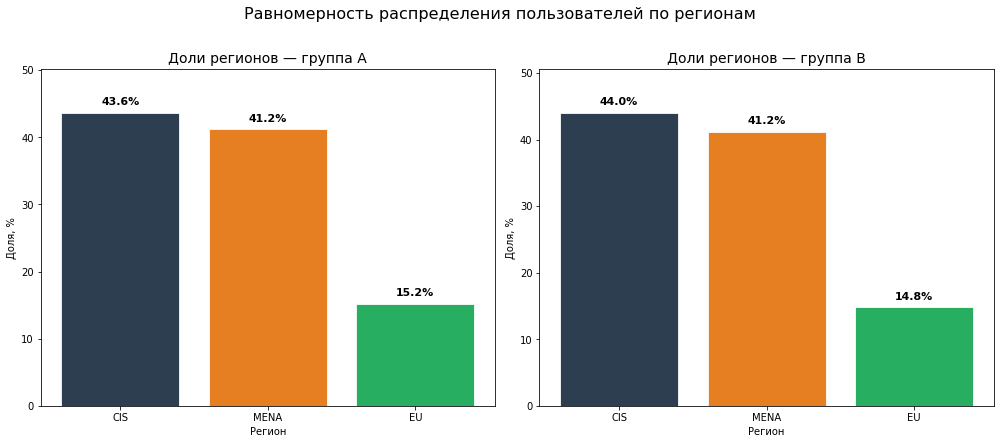

In [35]:
# Фиксированные цвета для каждого региона
region_colors = {
    'CIS':  '#2C3E50',   
    'MENA': '#E67E22',   
    'EU':   '#27AE60'    
}

# Формируем списки цветов в порядке регионов на графике
colors_A = [region_colors.get(reg, '#95A5A6') for reg in shares_A_pct.index]
colors_B = [region_colors.get(reg, '#95A5A6') for reg in shares_B_pct.index]

# Настройка графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data_pct, colors, group_name in [
    (axes[0], shares_A_pct, colors_A, 'A'),
    (axes[1], shares_B_pct, colors_B, 'B')
]:
    bars = ax.bar(data_pct.index, data_pct.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Доли регионов — группа {group_name}', fontsize=14)
    ax.set_xlabel('Регион')
    ax.set_ylabel('Доля, %')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, data_pct.max() * 1.15)  # запас сверху для подписей

    # Подписи процентов на столбцах
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + data_pct.max() * 0.02,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

plt.suptitle('Равномерность распределения пользователей по регионам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
<a id='12'></a>
### Вывод после проверки A/B-теста

* На основе проведённого анализа A/B-теста было обнаружено незначительная разница в количестве пользователей в двух группах (1477 против 1466), то есть объёмы выборок практически идентичны. 
* Отсутствие пересечений пользователей из тестовой и контрольной групп подтверждает независимость выборок.
* В распределении пользователей тестовой и контрольной групп по устройствам максимальные отклонения наблюдаются по категориям iPhone и Android, но они не превышают 1,7 п.п. Такие расхождения незначительные и допустимые при случайном распределении пользователей. В целом распределение по типам устройств можно признать сбалансированным.
* Наблюдаются небольшие отклонения в долях по регионам между группами (например, доля CIS в группе B выше на 0,4 п.п, а доля EU ниже на 0,4 п.п. по сравнению с группой A). Эти расхождения не выглядят критичными и могут объясняться естественной вариативностью при случайном распределении. В целом распределение по регионам можно считать достаточно равномерным.

Таким образом, все ключевые критерии корректного проведения A/B‑теста соблюдены, нарушений не обнаружено.

[Назад к содержанию](#start)

---
## Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

<a id='13'></a>
### Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [36]:
# Выгружаем данные в переменную df_sessions_test
df_sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [37]:
# Выводим первые строки датафрейма на экран
df_sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [38]:
# Выводим информацию о датафрейме
df_sessions_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100005 non-null  object
 1   session_id         100005 non-null  object
 2   session_date       100005 non-null  object
 3   session_start_ts   100005 non-null  object
 4   install_date       100005 non-null  object
 5   session_number     100005 non-null  int64 
 6   registration_flag  100005 non-null  int64 
 7   page_counter       100005 non-null  int64 
 8   region             100005 non-null  object
 9   device             100005 non-null  object
 10  test_group         100005 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


Датасет `sessions_project_test_part.csv` содержит 11 столбцов и 100 005 строк, в которых представлена информация о сессиях пользователей за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

* Названия столбцов отображаются корректно.
* Типы данных оптимальны.
* Пропусков в столбцах нет.
* Значения в столбцах соответствуют своему описанию.

In [39]:
# Создаем столбец good_session 
df_sessions_test['good_session'] = (df_sessions_test['page_counter'] >= 4).astype(int)

---
<a id='14'></a>
### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Так как цель нового алгоритма рекомендательной системы показывать более интересный контент, в качестве основной целевой метрики возьмём ***долю успешных первых сессий***.

Нулевая гипотеза (H0): новый алгоритм рекомендаций не влияет на вовлечённость пользователей. Доля успешных первых сессий в тестовой группе (B) выше, чем в контрольной группе (A) - рА=рВ. 

Альтернативная гипотеза (H1): новый алгоритм рекомендаций повышает вовлечённость пользователей. Доля успешных первых сессий в тестовой группе (B) статистически значимо выше, чем в контрольной группе (A) - рА<рВ.

До проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у нас данных о проведении эксперимента этих метрик нет. Если бы мы проводили этот эксперимент самостоятельно, то в качестве прокси-метрик стоило выбрать:
* среднее число просмотренных страниц за сессию — эта метрика напрямую отражает вовлечённость пользователя и интерес к контенту;
* частота кликов по рекомендациям (CTR на рекомендованные карточки) — если алгоритм лучше подбирает контент, пользователи будут чаще кликать;
* доля сессий с хотя бы одним взаимодействием (лайк, комментарий, репост) — показывает, насколько контент побуждает к активным действиям.

Для барьерных метрик подходит:
* Показатель отказов — доля сессий, в которых пользователь просмотрел только одну страницу и быстро ушёл.
* Время до первого взаимодействия — если пользователю приходится дольше искать интересный контент, это может ухудшать опыт, даже если в итоге он просматривает больше страниц.
* Доля негативных сигналов (например, «скрыть рекомендацию», «не интересно», дизлайки) — если алгоритм показывает более релевантный контент, таких сигналов должно становиться меньше.

---
<a id='15'></a>
### Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используя созданный ранее столбец `good_session` рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [40]:
# Фильтруем только первые сессии
df_first_sessions = df_sessions_test[df_sessions_test['session_number'] == 1]

In [41]:
# Считаем количество задействованных пользователей в тесте 
users_by_group = df_first_sessions.groupby('test_group')['user_id'].nunique()

total_users = users_by_group.sum()

In [42]:
# Считаем долю успешных первых сессий для каждой группы
success_rate = df_first_sessions.groupby('test_group')['good_session'].mean()

# Количество успешных сессий
success_count = df_first_sessions.groupby('test_group')['good_session'].sum()

rate_A = success_rate['A']
rate_B = success_rate['B']
diff = rate_B - rate_A          # абсолютная разница 
rel_diff = (diff / rate_A) * 100  # относительное изменение

print(f"\nГруппа A: {users_by_group['A']} пользователей, из них успешных сессий: {int(success_count['A'])}")
print(f"Группа B: {users_by_group['B']} пользователей, из них успешных сессий: {int(success_count['B'])}")
print(f"Группа A: {rate_A*100:.1f}%")
print(f"Группа B: {rate_B*100:.1f}%")
print(f"Абсолютная разница: {diff*100:.2f} процентных пунктов")
print(f"Относительное изменение: {rel_diff:.2f}%")


Группа A: 15162 пользователей, из них успешных сессий: 4787
Группа B: 15416 пользователей, из них успешных сессий: 4851
Группа A: 31.6%
Группа B: 31.5%
Абсолютная разница: -0.11 процентных пунктов
Относительное изменение: -0.33%


---
<a id='16'></a>
### Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Посмотрим полученное значение p-value и сделаем выводы о статистической значимости.

In [43]:
# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

# Считаем количество успехов (good_session == 1) и размер выборки по группам
m_a = df_first_sessions[df_first_sessions['test_group'] == 'A']['good_session'].sum()
n_a = len(df_first_sessions[df_first_sessions['test_group'] == 'A'])

m_b = df_first_sessions[df_first_sessions['test_group'] == 'B']['good_session'].sum()
n_b = len(df_first_sessions[df_first_sessions['test_group'] == 'B'])

p_a, p_b = m_a/n_a, m_b/n_b # Считаем доли успехов для каждой группы: A и B

# Проверяем предпосылку о достаточном количестве данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): 
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
    
alpha = 0.05# Устанавливаем уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # Проводим Z-тест пропорций
	[m_a, m_b],
	[n_a, n_b],
	alternative='smaller'
)

print(f'pvalue={p_value_ztest}') # Выводим полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
    print("Новый алгоритм не показал значимого улучшения доли успешных первых сессий")
else:
    print('Нулевая гипотеза не находит подтверждения!')
    print(f'Доля успешных первых сессий в тестовой группе (B) статистически значимо выше, чем в контрольной группе (A)')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.5783523649187868
Нулевая гипотеза находит подтверждение!
Новый алгоритм не показал значимого улучшения доли успешных первых сессий


---
<a id='17'></a>
### Вывод по результатам A/B-эксперимента

***Характеристики проведённого эксперимента:***
* Период проведения теста: с 14.10.2025 по 02.11.2025 (20 дней).
* Контрольная группа (A): 15 162 уникальных пользователей.
* Тестовая группа (B): 15 416 уникальных пользователей.

***Влияние нового алгоритма на ключевую метрику:***

Ключевая метрика — доля успешных первых сессий (сессия считается успешной, если пользователь просмотрел ≥ 4 страниц).

* Доля успешных сессий, группа A: 31,6%.
* Доля успешных сессий, группа B: 31,5%.
* Абсолютная разница (B − A): −0,11 процентных пункта.
* Относительное изменение: −0,33%.

Таким образом, новый алгоритм рекомендаций не привёл к росту ключевой метрики. Доля успешных первых сессий в тестовой группе оказалась незначимо ниже контрольной. Иными словами, пользователи, впервые взаимодействующие с лентой на новом алгоритме, вовлекаются не лучше, чем на текущей версии.

***Статистическая значимость эффекта***

Для проверки гипотезы использован Z‑тест для пропорций (односторонняя альтернатива: доля в группе B выше, чем в группе A).

* P‑value: 0,578 (57,8%).
* Уровень значимости: 0,05 (5 %).

Поскольку p‑value ≫ 0,05, нулевая гипотеза (об отсутствии различий между группами) не отвергается. Различие в долях успешных сессий статистически не значимо — наблюдаемая разница (−0,11 п. п.) объясняется естественным разбросом данных, а не действием нового алгоритма.

***Рекомендация***

Внедрять новый алгоритм в продакшен не рекомендуется. Результаты A/B-теста не подтверждают, что новый алгоритм рекомендаций улучшает вовлечённость пользователей на этапе первой сессии — ключевой метрике, критичной для удержания. Раскатка алгоритма в текущем виде не принесёт ожидаемого эффекта и может создать технический и операционный долг без бизнес-выгоды.

Перед повторным запуском эксперимента стоит:

1. Проанализировать причины отсутствия эффекта. Проверить, как именно работает новый алгоритм: какие типы контента он рекомендует, нет ли перекоса в сторону определённых категорий или слишком узких интересов. Возможно, алгоритм меняет структуру рекомендаций, но это не конвертируется в дополнительные просмотры.
2. Разбить аудиторию на сегменты и проверить метрику внутри них. Группировка по устройству (Android, iPhone, Mac, PC), региону (CIS, MENA, EU) или другому признаку может выявить, что алгоритм помогает одной части аудитории и вредит другой, а в среднем эффект «размывается». Это даст гипотезы для точечной доработки.
3. Пересмотреть пороговое условие успешности сессии. Порог «≥ 4 страниц» мог оказаться недостаточно чувствительным для фиксации изменений, которые алгоритм всё-таки вносит. 

[Назад к содержанию](#start)